<a href="https://colab.research.google.com/github/Cairo-Henrique/VQE-Quantum-Portfolio-Optimization/blob/main/vqe_knapsack_problem/VQE_Knapsack_QInvest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolução do Problema da Mochila com VQE
---
*Implementação utilizando Qiskit, QUBO e Variational Quantum Eigensolver (VQE).*

**Grupo 11 (QInvest)**

> Alexandre Barbosa de Almeida <br>
  Cainã Pessoa <br>
  Cairo Henrique Vaz Cotrim <br>
  Élen Silva Almeida <br>
  José de Anchieta C C Netto <br>
  Júlio César Reis da Silva <br>
  Leandro Luiz de Lima Freitas <br>
  Leonardo Alves Santana <br>
  Matheus Albert Oliveira dos Santos <br>
  Michel Pereira da Cunha


In [ ]:
# Instalação das bibliotecas necessárias
!pip install numpy qiskit qiskit-aer qiskit-nature qiskit-algorithms pylatexenc print-versions > /dev/null 2>&1

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from qiskit.circuit.library import n_local
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals

from typing import Any, Tuple, Dict
from print_versions import print_versions

# 1. Introdução

O Problema da Mochila (*Knapsack Problem*) é um problema clássico de otimização combinatória. O objetivo é selecionar um subconjunto de itens que maximize o valor total transportado sem ultrapassar a capacidade de peso da mochila.

Matematicamente, o problema pode ser formulado como:

\begin{align}
\text{função objetivo}:
&\quad \max \; \sum_{i=1}^{n} v_i x_i \\
\text{sujeito a}:
&\quad \sum_{i=1}^{n} w_i x_i \leq W, \tag{1} \\
\end{align}

onde:

- $n$ é o número total de itens;
- $v_i$ é o valor do item $i$;
- $w_i$ é o peso do item $i$;
- $W$ é a capacidade da mochila;
- $x_i \in \{0,1\}, \quad i = 1, \dots, n :$

$\hspace{1cm}
\begin{align}
& x_i =
\begin{cases}
1 & \text{se o item } i \text{ for escolhido;} \\
0 & \text{caso contrário.}
\end{cases}
\end{align}
$

Esse problema é NP-difícil, o que significa que sua complexidade cresce rapidamente com o número de itens.

Em formulações utilizadas em algoritmos variacionais quânticos, essa maximização é convertida em um problema de minimização da função de custo equivalente. Para permitir que a soma dos pesos seja menor ou igual à capacidade, introduzimos variáveis de folga $S$ (slack variables), transformando a desigualdade em uma igualdade que é incorporada como uma penalidade $\lambda$:

\begin{equation}
\min \left( -\sum_{i=1}^{n} v_i x_i + \lambda \left(\sum_{i=1}^{n} w_i x_i + S - W\right)^2 \right),
\tag{2}
\end{equation}

onde $S = \sum_{k=0}^{M-1} 2^k y_k$ representa a expansão binária da folga necessária para completar a capacidade $W$. Nesta formulação:

* O primeiro termo maximiza o valor total (minimizando o negativo da soma);
* O segundo termo pune qualquer combinação de itens e folga que não totalize exatamente $W$, forçando a condição $\sum w_i x_i \leq W$;
* $\lambda$ controla o rigor da punição para garantir que a restrição de capacidade seja respeitada frente ao objetivo de ganho.
* $S$ (Variáveis de Folga) representa o espaço vazio na mochila, permitindo que a restrição seja atendida mesmo quando a mochila não está cheia;
* O número de qubits de folga necessários é dado por $M = \lfloor \log_2(W) \rfloor + 1$.

# 2. Método

O problema da mochila é inicialmente formulado como um problema de otimização combinatória com variáveis binárias. Para que ele possa ser resolvido por um algoritmo variacional quântico, o problema é convertido para a forma QUBO (*Quadratic Unconstrained Binary Optimization*), que expressa a função objetivo como um polinômio quadrático em variáveis binárias. Em seguida, a formulação QUBO é transformada em um modelo de Ising, substituindo variáveis binárias por variáveis de *spin*. Essa representação permite construir um Hamiltoniano quântico em termos de operadores de Pauli Z, cuja energia esperada pode ser minimizada pelo algoritmo VQE (*Variational Quantum Eigensolver*).

O método utilizado segue as seguintes etapas:

1. Conversão do problema para uma formulação **QUBO** (variáveis binárias);
2. Conversão do QUBO em um **Modelo de Ising** (variáveis de *spin*);
3. Transformação do Modelo de Ising em um **Hamiltoniano quântico com operador Z-Pauli**, cujos autoestados $(\vert 0 \rangle$, $\vert 1 \rangle)$ e autovalores $(+1,-1)$ representam naturalmente as variáveis de escolha de itens e de *spin* do problema, respectivamente;
4. Construção de um **ansatz variacional**: heurística inicial de circuito quântico parametrizado para gerar estados candidatos;
5. Aplicação do **VQE** para minimizar a energia (função de custo);
6. Extração da ***bitstring*** mais provável como interpretação da solução da mochila.

A implementação foi feita usando o *framework* Qiskit, com as seguintes dependências e versões:

In [ ]:
print_versions(globals())

numpy==2.0.2
pandas==2.2.2
seaborn==0.13.2
networkx==3.6.1
qiskit==2.3.0
qiskit_algorithms==0.4.0


# 3. Formulação QUBO (*Quadratic Unconstrained Binary Optimization*)

A formulação QUBO é amplamente utilizada em computação quântica para problemas de otimização combinatória porque permite representar a função objetivo como um polinômio quadrático em variáveis binárias. A restrição de capacidade da mochila é incorporada na função objetivo por meio de um termo de penalidade.

Assim, o problema passa a ser escrito como uma função quadrática das variáveis binárias:

<br>

$$
E(x) = x^T Q x + c\,,
\tag{3}
$$

onde:

- $x$ é o vetor de variáveis binárias $x_i \in \{0,1\}$, contendo as variáveis de decisão dos itens e as variáveis de folga da expansão binária;

- $Q$ é uma matriz de dimensão $(n+M) \times (n+M)$ que codifica tanto os valores dos itens (na diagonal principal) quanto as penalidades quadráticas de interação resultantes do termo $(\sum w_i x_i + S - W)^2$ da Eq. (2);

- $c$ é um termo constante.

Minimizar essa função é equivalente a encontrar a melhor solução do problema original.

Essa estrutura pode ser facilmente convertida para o modelo de Ising e, posteriormente, para um Hamiltoniano quântico em termos de operadores de Pauli. Como algoritmos variacionais como o VQE buscam o estado de menor energia de um Hamiltoniano, a formulação QUBO fornece um caminho direto para mapear problemas clássicos de otimização para o domínio quântico.

In [ ]:
def knapsack_qubo(
    values: list[float],
    weights: list[float],
    capacity: float,
    penalty: float
) -> tuple[np.ndarray, float]:
    """
    Constrói a matriz QUBO para o problema da mochila com restrição de desigualdade.

    O objetivo é maximizar o valor total respeitando a restrição de peso
    (soma dos pesos <= capacidade). A restrição é incorporada através de um
    termo de penalidade usando variáveis de folga (slack variables) em
    expansão binária.

    Parameters
    ----------
    values : list[float]
        Valor associado a cada item.
    weights : list[float]
        Peso associado a cada item.
    capacity : float
        Capacidade máxima de peso da mochila.
    penalty : float
        Coeficiente de penalidade usado para forçar a restrição de capacidade.

    Returns
    -------
    Q : np.ndarray
        Matriz QUBO representando a função de custo quadrática.
    const : float
        Termo constante da função de custo que não depende das variáveis.
    """
    n = len(values)

    # Calcular os pesos das variáveis de folga (Log-Trick)
    # Convertendo a capacidade para inteiro para criar a expansão binária da folga
    max_slack = int(capacity)
    slack_weights = []
    power = 1

    while max_slack >= power:
        slack_weights.append(float(power))
        max_slack -= power
        power *= 2

    # Adiciona o restante (se houver) para cobrir exatamente o valor de 'capacity'
    if max_slack > 0:
        slack_weights.append(float(max_slack))

    m = len(slack_weights)
    total_vars = n + m

    # Vetor de coeficientes (C) combinando os pesos dos itens e os pesos das folgas
    C = weights + slack_weights

    Q = np.zeros((total_vars, total_vars))

    # Preencher a matriz QUBO
    for i in range(total_vars):
        # Termo de penalidade na diagonal para todas as variáveis
        Q[i, i] += penalty * (C[i] ** 2) - 2 * penalty * capacity * C[i]

        # Termo da função objetivo (apenas para as variáveis originais dos itens)
        if i < n:
            Q[i, i] -= values[i]

    # Termos fora da diagonal (apenas penalidade de interação)
    for i in range(total_vars):
        for j in range(i + 1, total_vars):
            Q[i, j] += 2 * penalty * C[i] * C[j]

    const = penalty * (capacity ** 2)

    return Q, const

# 4. Modelo de Ising

Em computação quântica, é comum representar problemas de otimização utilizando o modelo de Ising. Para isso, as variáveis binárias:

$$
x_i \in \{0,1\},
$$

são transformadas em variáveis de spin:


$$
z_i \in \{-1,+1\},
\tag{4}
$$

por meio da relação:


$$
x_i = \frac{1 - z_i}{2}.
\tag{5}
$$

Após essa transformação, a função custo passa a ser representada como um Hamiltoniano do tipo:

<br>

$$
H =
\sum_i h_i z_i
+
\sum_{i<j} J_{ij} z_i z_j
+
c\,.
\tag{6}
$$

onde:

- $h_i$ são os termos lineares;
- $J_{ij}$ são os acoplamentos entre qubits;
- $c$ é uma constante.


In [ ]:
def qubo_to_ising(
    Q: np.ndarray,
    const: float = 0.0
) -> tuple[np.ndarray, Dict[tuple[int, int], float], float]:
    """
    Converte o modelo QUBO para a forma Ising.

    Parameters
    ----------
    Q : np.ndarray
        QUBO matrix defining the quadratic binary optimization problem.
        It is assumed to be an n × n matrix.
    const : float, optional
        Constant term of the QUBO cost function. Default is 0.0.

    Returns
    -------
    h : np.ndarray
        Vector of local field coefficients in the Ising model.
    J : dict[tuple[int, int], float]
        Dictionary representing pairwise spin interactions. Keys are tuples
        (i, j) indicating the interacting spins, and values are the
        corresponding coupling strengths.
    const : float
        Constant energy offset of the Ising Hamiltonian.
    """

    n = Q.shape[0]

    h = np.zeros(n)
    J = {}

    for i in range(n):
        qii = Q[i, i]
        const += qii / 2
        h[i] += -qii / 2

    for i in range(n):
        for j in range(i + 1, n):

            qij = Q[i, j]

            if abs(qij) < 1e-12:
                continue

            const += qij / 4

            h[i] += -qij / 4
            h[j] += -qij / 4

            J[(i, j)] = qij / 4

    return h, J, const

# 5. Hamiltoniano Quântico

O modelo de Ising pode ser expresso utilizando operadores de Pauli, permitindo representar o problema como um Hamiltoniano quântico. Neste caso, o Hamiltoniano assume a forma:

$$
H =
c \cdot I
+
\sum_i h_i Z_i
+
\sum_{i<j} J_{ij} Z_i Z_j.
\tag{7}
$$

onde:

- $I$ é o operador identidade;

- $Z$ é o operador de Pauli-$Z$.

Aqui, $Z_i$ representa o operador de Pauli-$Z$ aplicado ao qubit $i$.

Em um sistema com vários qubits, ele atua apenas nesse qubit e como identidade nos demais:

$$
Z_i = \underbrace{I}_{\text{posição 1}} \otimes \cdots \otimes I \otimes \underbrace{Z}_{\text{posição i}} \otimes I \otimes \cdots \otimes \underbrace{I}_{\text{posição n}},
\tag{8}
$$

onde o operador $Z$ aparece na posição $i$.

In [ ]:
def ising_to_pauli_op(
    h: np.ndarray,
    J: Dict[tuple[int, int], float],
    const: float
) -> SparsePauliOp:
    """
    Converte o modelo Ising em um operador Pauli.

    Esse operador é utilizado pelo algoritmo VQE
    para calcular o valor esperado da energia.

    Parameters
    ----------
    h : np.ndarray
        Vector of local field coefficients of the Ising model.
    J : dict[tuple[int, int], float]
        Dictionary representing pairwise spin interactions. Keys are tuples
        (i, j) indicating interacting spins, and values are the corresponding
        coupling strengths.
    offset : float
        Constant energy offset of the Hamiltonian.

    Returns
    -------
    SparsePauliOp
        Quantum operator representing the Ising Hamiltonian expressed as a
        linear combination of Pauli operators.
    """

    n = len(h)

    paulis = []
    coeffs = []

    paulis.append("I" * n)
    coeffs.append(const)

    for i, coeff in enumerate(h):

        if abs(coeff) < 1e-12:
            continue

        label = ["I"] * n
        label[n - 1 - i] = "Z"

        paulis.append("".join(label))
        coeffs.append(coeff)

    for (i, j), coeff in J.items():

        label = ["I"] * n
        label[n - 1 - i] = "Z"
        label[n - 1 - j] = "Z"

        paulis.append("".join(label))
        coeffs.append(coeff)

    return SparsePauliOp(paulis, coeffs)

# 6. Variational Quantum Eigensolver (VQE)

Para encontrar a solução do problema utilizamos o método variacional VQE, um algoritmo híbrido quântico-clássico utilizado para estimar o menor autovalor de um Hamiltoniano.

O VQE se baseia no princípio variacional da mecânica quântica, que afirma que para qualquer estado quântico $|\psi\rangle$:

<br>

$$
E(\psi) = \langle \psi | H | \psi \rangle \geq E_0.
\tag{9}
$$

onde:
- $H$ é o Hamiltoniano do problema;
- $E(\psi)$ é o valor esperado da energia do estado escolhido;
- $E_0$ é a energia mínima do sistema (estado fundamental).

Encontrar o estado de menor energia corresponde a encontrar a melhor solução do problema de otimização. Como o princípio variacional denota um limite superior para a menor energia, minimizar o valor esperado significa chegar mais próximo da menor energia.

# 7 Ansatz Variacional

O VQE utiliza um circuito quântico parametrizado chamado ansatz, que gera um estado dependente de parâmetros $|\psi(\theta)\rangle$, onde:

$$
\theta = (\theta_1, \theta_2, ..., \theta_n),
\tag{10}
$$

são parâmetros ajustáveis do circuito.

Esse estado é preparado a partir do estado inicial:

$$
|\psi(\theta)\rangle = U(\theta)|0\rangle.
\tag{11}
$$

## 7.1 Função Custo do VQE

O objetivo do algoritmo é minimizar a energia associada ao estado variacional:

$$
E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle\,,
\tag{12}
$$

Como o Hamiltoniano é uma soma de operadores de Pauli:

<br>

$$
H = \sum_i c_i P_i\,\,,
\tag{13}
$$

então a energia pode ser calculada como:

$$
E(\theta) = \sum_i c_i \langle \psi(\theta) | P_i | \psi(\theta) \rangle\,,
\tag{14}
$$

onde:

- $c_i$ são coeficientes reais;
- $P_i$ são operadores de Pauli.

# 8. Processo de Otimização

O VQE funciona por meio de um loop híbrido quântico-clássico:

 - `run_vqe_knapsack()`;

1. O circuito quântico é um ansatz do tipo Hardware-Efficient, que gera o estado candidato $|\psi(\theta)\rangle$:

    ```
    ansatz = n_local(
        num_qubits=n,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cz",
        entanglement="full",
        reps=reps,
    )
    ```
    onde:

    - `[ry,rz]` aplica rotações parametrizadas em cada qubit;

    - `cz` cria emaranhamento entre qubits;

    - `reps` controla a profundidade do circuito.

2. O computador quântico mede a energia $E(\theta)$:

    - `StatevectorEstimator()`;

    Calcula exatamente o valor esperado do Hamiltoniano em simulação por vetor de estado para testes locais, evitando ruído e facilitando a análise.

3. Um **otimizador clássico** atualiza os parâmetros $\theta \rightarrow \theta'$:

    - `SPSA(maxiter=maxiter)`;

    No caso, foi utilizada a Aproximação Estocástica de Perturbação Simultânea (SPSA, em inglês). Esse método consiste em aproximar o gradiente da função custo com apenas duas medições dela, e então atualizar os parâmetros com a técnica do gradiente descendente. Como cada avaliação da função custo exige executar o circuito muitas vezes, a aproximação desse otimizador o torna bastante útil.

4. *Fitness* (função de avaliação):

    - `best_feasible_from_probs()`;

    Avalia as soluções candidatas e seleciona a melhor a partir da distribuição de probabilidades.

4. O processo se repete até que a energia seja minimizada.


Ao final, a medição do estado quântico produz uma sequência de bits (*bitstring*) que representa a solução encontrada para o problema.

In [ ]:
def evaluate_knapsack(
    bitstring: str,
    values: list[float],
    weights: list[float],
    capacity: float
) -> tuple[float, float, bool]:
    """
    Avalia uma solução candidata para o problema da mochila.

    Parameters
    ----------
    bitstring : str
        Binary string representing the candidate solution. Each character up to n
        corresponds to an item, where '1' indicates that the item is included
        in the knapsack and '0' indicates that it is excluded.
        The following characters correspond to the slack variable.
    values : list[float]
        Value associated with each item.
    weights : list[float]
        Weight associated with each item.
    capacity : float
        Maximum allowed weight of the knapsack.

    Returns
    -------
    value : float
        Total value of the selected items.
    weight : float
        Total weight of the selected items.
    feasible : bool
        Boolean indicating whether the solution satisfies the capacity
        constraint (True if weight ≤ capacity, otherwise False).
    """

    n = len(values)

    x = np.array([int(b) for b in bitstring])
    x = x[:n] # Pegamos apenas os primeiros n bits, que representam as variáveis de decisão dos itens

    value = np.dot(values, x)
    weight = np.dot(weights, x)

    feasible = weight <= capacity

    return value, weight, feasible

In [ ]:
def best_feasible_from_probs(
    probs: Dict[str, float],
    values: list[float],
    weights: list[float],
    capacity: float
) -> tuple[str | None, float, float | None, float]:
    """
    Select the best feasible solution from a probability distribution
    produced by a quantum algorithm.

    Parameters
    ----------
    probs : dict[str, float]
        Probability distribution over bitstrings, typically obtained from
        a quantum statevector or measurement counts. Keys correspond to
        bitstrings and values correspond to their probabilities.
    values : list[float]
        Value associated with each item.
    weights : list[float]
        Weight associated with each item.
    capacity : float
        Maximum weight capacity of the knapsack.

    Returns
    -------
    best_bitstring : str | None
        Bitstring corresponding to the best feasible solution found.
        Returns None if no feasible configuration exists.
    best_value : float
        Total value of the selected items in the best feasible solution.
    best_weight : float | None
        Total weight of the selected items.
    best_prob : float
        Probability associated with the selected bitstring in the quantum
        state distribution.
    """

    best_value = -1
    best_bitstring = None
    best_weight = None
    best_prob = 0

    for bitstring, prob in probs.items():

        value, weight, feasible = evaluate_knapsack(
            bitstring, values, weights, capacity
        )

        if feasible and value > best_value:

            best_value = value
            best_bitstring = bitstring
            best_weight = weight
            best_prob = prob

    return best_bitstring, best_value, best_weight, best_prob

In [ ]:
def brute_force_knapsack(
    values: list[float],
    weights: list[float],
    capacity: float
) -> tuple[str | None, float, float | None]:
    """
    Solve the 0/1 Knapsack problem via exhaustive search.

    Parameters
    ----------
    values : list[float]
        Value associated with each item.
    weights : list[float]
        Weight associated with each item.
    capacity : float
        Maximum allowed weight of the knapsack.

    Returns
    -------
    best_bitstring : str | None
        Bitstring corresponding to the optimal item selection.
        Returns None if no feasible configuration exists.
    best_value : float
        Maximum achievable total value under the capacity constraint.
    best_weight : float | None
        Total weight of the selected items in the optimal solution.
    """

    n = len(values)

    best_value = -1
    best_weight = None
    best_bitstring = None

    for s in range(2 ** n):

        bitstring = format(s, f"0{n}b")

        value, weight, feasible = evaluate_knapsack(
            bitstring, values, weights, capacity
        )

        if feasible and value > best_value:
            best_value = value
            best_weight = weight
            best_bitstring = bitstring

    return best_bitstring, best_value, best_weight

In [ ]:
def run_vqe_knapsack(
    penalty: float,
    values: list[float],
    weights: list[float],
    capacity: float,
    reps: int = 2,
    maxiter: int = 500
) -> dict[str, Any]:
    """
    Executa o algoritmo VQE para resolver o problema da mochila.

    Parameters
    ----------
    penalty : float
        Penalty coefficient used to enforce the knapsack capacity constraint in
        the QUBO formulation.
    values : list[float]
        Value associated with each item.
    weights : list[float]
        Weight associated with each item.
    capacity : float
        Maximum weight capacity of the knapsack.
    reps : int, optional
        Number of repetitions (layers) of the variational ansatz. Higher values
        increase the expressive power of the circuit at the cost of a larger
        parameter space. Default is 2.
    maxiter : int, optional
        Maximum number of iterations of the classical optimizer. Default is 500.

    Returns
    -------
    dict[str, Any]
        Dictionary containing the main objects and results of the VQE
        execution, including:

        - ``ansatz`` : parametrized quantum circuit used by the VQE;
        - ``vqe_result`` : raw optimization result returned by the VQE;
        - ``optimal_circuit`` : ansatz instantiated with the optimal parameters;
        - ``history`` : list of energy values recorded during optimization;
        - ``probs`` : probability distribution over computational basis states;
        - ``best_bitstring_vqe`` : best feasible bitstring found from the final
          quantum state;
        - ``best_value_vqe`` : total value of the best VQE solution;
        - ``best_weight_vqe`` : total weight of the best VQE solution;
        - ``probability`` : probability associated with the selected bitstring;
        - ``best_bitstring_exact`` : optimal bitstring found by brute force;
        - ``best_value_exact`` : optimal total value found classically;
        - ``best_weight_exact`` : corresponding total weight.
    """

    Q, const = knapsack_qubo(values, weights, capacity, penalty)
    h, J, offset = qubo_to_ising(Q, const)
    hamiltonian = ising_to_pauli_op(h, J, offset)

    num_qubits = Q.shape[0] # Pega o tamanho N + M

    ansatz = n_local(
        num_qubits=num_qubits,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cz",
        entanglement="full",
        reps=reps,
    )

    estimator = StatevectorEstimator()
    optimizer = SPSA(maxiter=maxiter)

    history = []

    def callback(eval_count, params, value, metadata):
        history.append((eval_count, float(np.real(value))))

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback,
    )

    result = vqe.compute_minimum_eigenvalue(hamiltonian)

    optimal_circuit = ansatz.assign_parameters(result.optimal_point)
    psi = Statevector.from_instruction(optimal_circuit)
    probs = psi.probabilities_dict()

    best_bitstring, value, weight, prob = best_feasible_from_probs(
        probs, values, weights, capacity
    )

    exact_bitstring, exact_value, exact_weight = brute_force_knapsack(
        values, weights, capacity
    )


    return {

    "ansatz": ansatz,
    "vqe_result": result,
    "optimal_circuit": optimal_circuit,

    "history": history,

    "probs": probs,

    "best_bitstring_vqe": best_bitstring,
    "best_value_vqe": value,
    "best_weight_vqe": weight,
    "probability": prob,

    "best_bitstring_exact": exact_bitstring,
    "best_value_exact": exact_value,
    "best_weight_exact": exact_weight
    }

# 9. Resultados

In [ ]:
# Semente para garantir reprodutibilidade nos experimentos
np.random.seed(42)
algorithm_globals.random_seed = 42

## 9.1 Definição da instância do problema da mochila (Knapsack).

- values  -> valor de cada item

- weights -> peso de cada item

- capacity -> capacidade máxima da mochila

In [ ]:
# Exemplo
values = [10, 7, 15, 6]
weights = [2, 3, 5, 7]
capacity = 10

# values = [6,4,5]
# weights = [2,3,4]
# capacity = 5

## 9.2 Hyperparameter tuning

In [ ]:
k_values = [0.5, 1, 2, 5]  # fator multiplicativo da penalidade (penalty = k * sum(values))
reps_list = [1, 2, 3]      # profundidade do ansatz variacional
maxiters = [500, 1000]     # número máximo de iterações do otimizador


results = []

for k, reps, maxiter in itertools.product(k_values, reps_list, maxiters):

    penalty = k * sum(values)

    res = run_vqe_knapsack(
        penalty,
        values,
        weights,
        capacity,
        reps=reps,
        maxiter=maxiter
    )

    results.append({
        "k": k,
        "penalty": penalty,
        "reps": reps,
        "maxiter": maxiter,
        "value_vqe": res["best_value_vqe"],
        "probability": res["probability"],
        "value_exact": res["best_value_exact"]
    })

df = pd.DataFrame(results)
df.sort_values("value_vqe", ascending=False)

,k,penalty,reps,maxiter,value_vqe,probability,value_exact
0,0.5,19.0,1,500,32,7.162892e-02,32
1,0.5,19.0,1,1000,32,1.923676e-21,32
2,0.5,19.0,2,500,32,3.845020e-06,32
3,0.5,19.0,2,1000,32,1.374769e-09,32
4,0.5,19.0,3,500,32,7.773515e-02,32
5,0.5,19.0,3,1000,32,3.990922e-06,32
6,1.0,38.0,1,500,32,1.079686e-15,32
7,1.0,38.0,1,1000,32,1.246260e-14,32
8,1.0,38.0,2,500,32,2.575326e-04,32
9,1.0,38.0,2,1000,32,3.510941e-03,32


Observa-se que todas as configurações testadas foram capazes de identificar
a solução ótima do problema da mochila, com valor igual a 32, que coincide
com a solução obtida por busca exaustiva.

Entretanto, a probabilidade associada ao bitstring ótimo varia significativamente entre as configurações.

Esses resultados sugerem que o desempenho do VQE depende sensivelmente
da escolha de hiperparâmetros, mesmo em instâncias pequenas do problema.


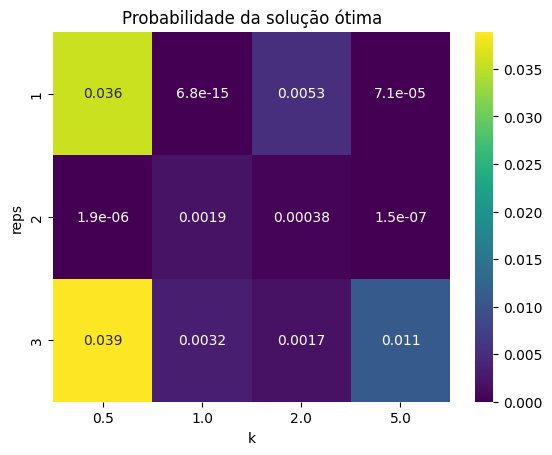

In [ ]:
sns.heatmap(
    df.pivot_table(
        values="probability",
        index="reps",
        columns="k"
    ),
    annot=True,
    cmap="viridis"
)

plt.title("Probabilidade da solução ótima")
plt.show()

Embora o VQE encontre consistentemente a solução ótima em termos de valor da mochila, a probabilidade associada ao estado correspondente pode ser relativamente baixa. Esse comportamento é típico de algoritmos variacionais, que minimizam a energia esperada do Hamiltoniano, mas não necessariamente concentram amplitude no estado ótimo individual.

## 9.3 Executando VQE novamente com os melhores parâmetros

In [ ]:
# selecionar melhor configuração
best_row = df.sort_values(
    ["value_vqe", "probability"],
    ascending=[False, False]
).iloc[0]


# executando o VQE para os melhores parâmetros
best_k = best_row["k"]
best_reps = best_row["reps"]
best_maxiter = best_row["maxiter"]

best_penalty = best_k * sum(values)

best_result = run_vqe_knapsack(
    penalty=best_penalty,
    values=values,
    weights=weights,
    capacity=capacity,
    reps=int(best_reps),
    maxiter=int(best_maxiter)
)

n = len(values)

# imprimir o resultado final
print("\n=== Melhor configuração encontrada ===")

print(f"k = {best_k}")
print(f"Penalty = {best_penalty}")
print(f"Reps = {best_reps}")
print(f"MaxIter = {best_maxiter}")


print("\n=== Resultado VQE ===")

print("Bitstring (itens):", best_result["best_bitstring_vqe"][:n])
print("Bitstring (valor de folga):", best_result["best_bitstring_vqe"][n:])
print("Valor:", best_result["best_value_vqe"])
print("Peso:", best_result["best_weight_vqe"])
print("Probabilidade:", best_result["probability"])


print("\n=== Solução Exata ===")

print("Bitstring:", best_result["best_bitstring_exact"])
print("Valor:", best_result["best_value_exact"])
print("Peso:", best_result["best_weight_exact"])


=== Melhor configuração encontrada ===
k = 0.5
Penalty = 19.0
Reps = 3.0
MaxIter = 500.0

=== Resultado VQE ===
Bitstring (itens): 1110
Bitstring (valor de folga): 0000
Valor: 32
Peso: 10
Probabilidade: 0.0963328012959821

=== Solução Exata ===
Bitstring: 1110
Valor: 32
Peso: 10


## 9.4 Visualização dos resultados obtidos com a melhor configuração de hiperparâmetros

### 9.4.1 Visualização do Circuito (VQE)

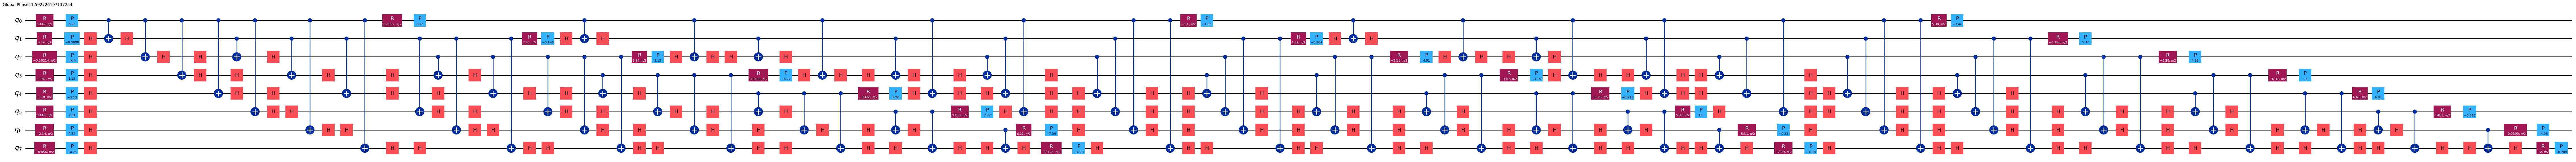

In [ ]:
optimal_circuit = best_result["ansatz"].assign_parameters(best_result["vqe_result"].optimal_point)
optimal_circuit.decompose().draw("mpl", fold=-1)

### 9.4.2 Gráfico da energia estimada durante o processo de otimização

O VQE minimiza o valor esperado do Hamiltoniano. Portanto,
espera-se que a energia diminua ao longo das iterações até
atingir um ponto de convergência.


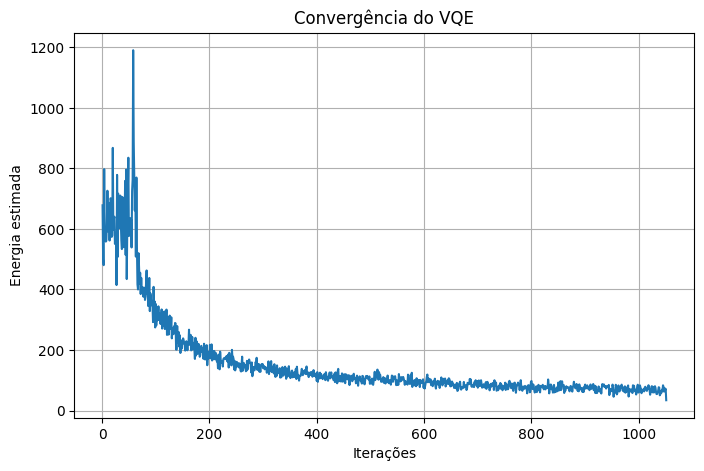

In [ ]:
history = best_result["history"]

iters = [h[0] for h in history]
energy = [h[1] for h in history]

plt.figure(figsize=(8,5))

plt.plot(iters, energy)

plt.xlabel("Iterações")
plt.ylabel("Energia estimada")
plt.title("Convergência do VQE")

plt.grid()

plt.show()

O gráfico de convergência mostra que o algoritmo VQE consegue reduzir
gradualmente a energia estimada do Hamiltoniano ao longo das iterações,
indicando que o processo de otimização está funcionando corretamente.

### 9.4.3 Distribuição de probabilidades dos bitstrings obtidos pelo VQE

Cada bitstring representa uma combinação de itens na mochila.
A altura da barra indica a probabilidade observada daquele estado
na função de onda final do circuito variacional.

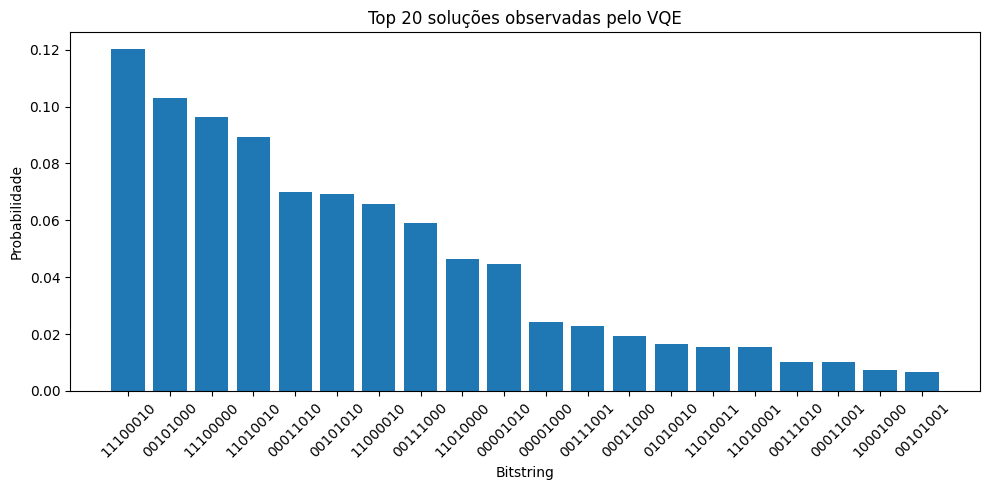

In [ ]:
probs = best_result["probs"]

# Ordenar por probabilidade
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)

# Pegar apenas as top_k maiores
top_k = 20
top_probs = dict(sorted_probs[:top_k])

plt.figure(figsize=(10,5))
plt.bar(top_probs.keys(), top_probs.values())

plt.xlabel("Bitstring")
plt.ylabel("Probabilidade")
plt.title(f"Top {top_k} soluções observadas pelo VQE")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

A distribuição de probabilidades revela como a função de onda final do
circuito variacional se distribui entre os diferentes estados possíveis.
Nem sempre a solução ótima possui a maior probabilidade, pois o VQE
minimiza a energia média do Hamiltoniano e não diretamente a
probabilidade de um estado específico.

### 9.4.4 Visualização do valor associado a cada bitstring possível

As barras verdes representam soluções viáveis (peso dentro da
capacidade da mochila), enquanto barras vermelhas indicam
soluções inviáveis que violam a restrição de peso.

Esse gráfico permite compreender melhor a estrutura do espaço
de busca do problema.


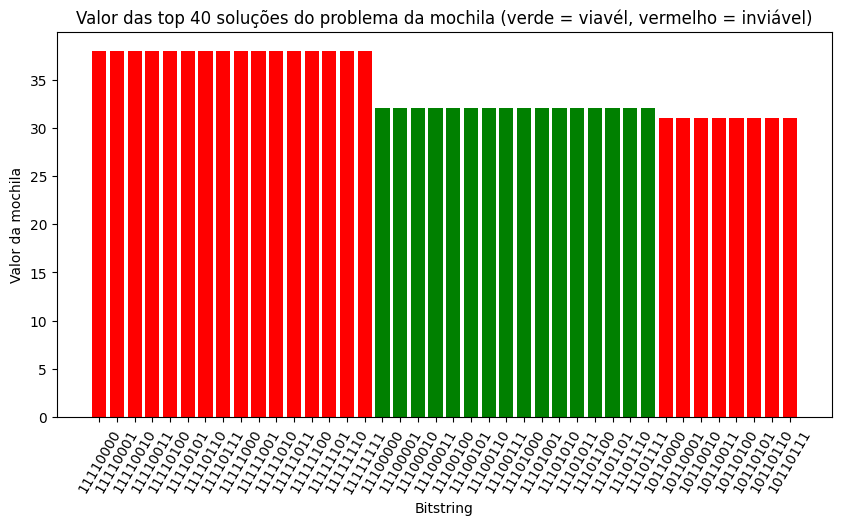

In [ ]:
values_list = []
labels = []
colors = []

for bitstring in probs.keys():

    value, weight, feasible = evaluate_knapsack(
        bitstring, values, weights, capacity
    )

    labels.append(bitstring)
    values_list.append(value)

    if feasible:
        colors.append("green")
    else:
        colors.append("red")

# Juntar tudo
data = list(zip(labels, values_list, colors))

# Ordenar pelo valor da mochila
data_sorted = sorted(data, key=lambda x: x[1], reverse=True)

# Pegar apenas top_k
top_k = 40
top_data = data_sorted[:top_k]

labels_top, values_top, colors_top = zip(*top_data)

plt.figure(figsize=(10,5))

plt.bar(labels_top, values_top, color=colors_top)

plt.xlabel("Bitstring")
plt.ylabel("Valor da mochila")

plt.title(f"Valor das top {top_k} soluções do problema da mochila (verde = viavél, vermelho = inviável)")

plt.xticks(rotation=60)

plt.show()

Por fim, o gráfico de valores das soluções permite visualizar a estrutura
do espaço de busca do problema da mochila, destacando quais combinações
de itens são viáveis e quais violam a restrição de capacidade.

# 10. Conclusão

Neste notebook exploramos a aplicação do algoritmo Variational Quantum
Eigensolver (VQE) para resolver um problema de otimização do tipo mochila
(knapsack). O problema foi formulado como um modelo QUBO e mapeado para
um Hamiltoniano de Ising, permitindo sua avaliação por meio de um circuito
quântico variacional.

A análise de hiperparâmetros, como o coeficiente de penalidade e a
profundidade do ansatz, mostrou que o VQE pode encontrar a solução ótima,
mas a probabilidade de medi-la depende da escolha desses parâmetros.

Testes com diferentes instâncias do problema foram realizados, e no exemplo
apresentado a solução encontrada pelo VQE coincide com a solução obtida
por busca exaustiva, evidenciando o potencial do método para problemas de
otimização combinatória.